# Fabey Perot interference
A light incident on a film encounters infinite reflections, which lead to the interference.
In this example, we consider the case where light is normally incident on a film of $\epsilon$  and thickness $d$.
The transmission $T$ is a function of $\omega$,

$$T = \frac{1}{1+F\sin^2\frac{\delta}{2}}$$

$$F = \frac{4R}{(1-R)^2}$$

$$R = |r|^2 $$

$$ r = \frac{\sqrt{\epsilon}-1}{\sqrt{\epsilon}+1}$$

$$ \delta = \frac{4 n \pi d}{\lambda} = 2nkd = \frac{2n\omega d}{c} $$

$$n=\sqrt{\epsilon}$$

## Meep unit
In numerical simulations, it is common to use a different unit for convinience.
 The light speed $c$ is set to 1. In this definition, $c = f \lambda$ becomes
 $$ 1 = f \lambda.$$ Thus, the unit of $f$ is $1/\lambda$. In meep, a length 1 
means 1 micron = 1000 nm, where the corresponding frequency is $f = 1/1 =1$ $\frac{1}{\mu\mathrm{m}}$. If you want to convert this $f$ in the usual unit,
you have to devide it by $ c = 3\times 10^{14} \mu$m/sec
$$f_u = f \times 3 \times 10^{14}~1/\mathrm{sec},$$ 
where $f_u$ is the usual frequency. For example, a $f = 1$ in the Meep unit correspond to $f_u = 300$ THz.

In [12]:
import numpy as np
Nf = 200
fmin = 1 # 1/micron => 300 THz
fmax = 3 # 1/micron => 900 THz
fre = np.linspace(fmin, fmax, Nf)
d = 0.5 # thickness = 500 nm 
epsi = 12
r = (np.sqrt(epsi) - 1)/( np.sqrt(epsi) + 1 )
R = np.abs(r**2)
F = 4 * R/(1 - R)**2

`fre` is a 1D array of frequencies with $N_f$ elements ranging from $f_{min}$ to $f_{max}$

In [13]:
omega = 2 * np.pi * fre
delta = 2*omega * d * np.sqrt(epsi)
T_ana = 1 / (1 + F * np.sin(delta/2)**2)

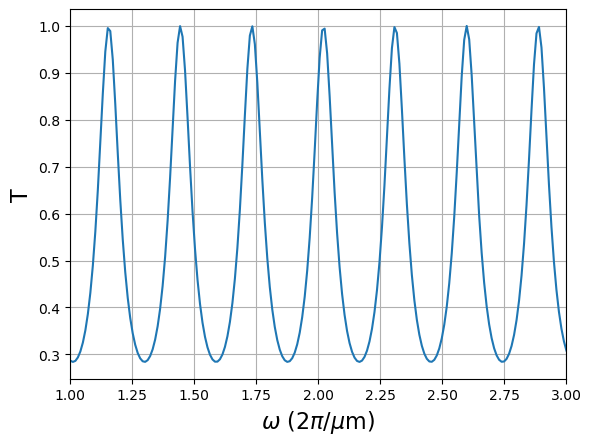

In [14]:
from matplotlib import pyplot as plt 
plt.figure(dpi=100)
plt.plot(omega/2/np.pi,T_ana)
plt.xlabel('$\omega$ (2$\pi/\mu$m)',fontsize = 16)
plt.ylabel('T',fontsize = 16)
plt.xlim([fmin,fmax])
plt.grid()
plt.show()


## Numerical approach to get $T$

In [15]:
import meep as mp

resolution = 500                 # pixels/um lower in 3D
dpml = 1.0                      # PML thickness
sx = 0.1
sy = 0.1
sz = 6 + 2*dpml
cell_size = mp.Vector3(sx,sy,sz)
pml_layers = [mp.PML(dpml,direction=mp.Z)]
k_point = mp.Vector3(0,0,0)
fcen = (fmin+fmax)/2          # center frequency
df = (fmax-fmin)                  # frequency width
dimensions = 1

In [6]:
sources = [mp.Source(mp.GaussianSource(fcen,fwidth=df),
                     component=mp.Ex, 
                     center=mp.Vector3(0,0,-2),
                    size=mp.Vector3(sx,sy,0)
                    )]


## Use Poynting Vector to Compute Transmittance 

In [7]:
sim_vac = mp.Simulation(cell_size=cell_size,
                        boundary_layers=pml_layers,
                        sources=sources,
                        dimensions=dimensions,
                        resolution=resolution,
                        k_point = k_point
                       )

tran_fr = mp.FluxRegion(center=mp.Vector3(0,0,2),size=mp.Vector3(sx,sy,0))
tran = sim_vac.add_flux(fcen, df, Nf, tran_fr)
   
sim_vac.run(until_after_sources=mp.stop_when_fields_decayed(50, mp.Ex,
                                                        mp.Vector3(z=0), 1e-3))
freqs = mp.get_flux_freqs(tran)


-----------
Initializing structure...
time for choose_chunkdivision = 0.000307798 s
Working in 1D dimensions.
Computational cell is 0 x 0 x 8 with resolution 100
time for set_epsilon = 0.000256062 s
-----------
field decay(t = 50.005): 0.25089646922627046 / 0.25089646922627046 = 1.0
field decay(t = 100.01): 8.947859345089917e-16 / 0.25089646922627046 = 3.566355227191463e-15
run 0 finished at t = 100.01 (20002 timesteps)


In [8]:
wvls = np.empty(Nf)
T = np.empty(Nf)
empty_flux = np.empty(Nf)
for i in range(Nf):
        wvls[i] = 1/freqs[i]
        (Ex,Ey,Hx,Hy)  = [sim_vac.get_dft_array(tran,c,i) for c in [mp.Ex, mp.Ey, mp.Hx, mp.Hy]]
        flux_density   = 1/2 * np.real( np.conj(Ex)*Hy - np.conj(Ey)*Hx )    # array
        (x,y,z,w)      = sim_vac.get_array_metadata(dft_cell=tran)          # w:weight see https://meep.readthedocs.io/en/latest/Python_User_Interface/#array-metadata
        empty_flux[i]  = np.sum(w*flux_density)                        # scalar

In [9]:
#sim_poyn.reset_meep()
geometry = [mp.Block(mp.Vector3(mp.inf,mp.inf,d), center=mp.Vector3(0,0,0),
                     material= mp.Medium(epsilon=epsi))]

sim_poyn = mp.Simulation(cell_size=cell_size,
                        geometry=geometry,
                        boundary_layers=pml_layers,
                        sources=sources,
                        dimensions=dimensions,
                        resolution=resolution,
                        k_point = k_point)
tran_fr = mp.FluxRegion(center=mp.Vector3(0,0,2),size=mp.Vector3(sx,sy,0))
tran = sim_poyn.add_flux(fcen, df, Nf, tran_fr)

sim_poyn.run(until_after_sources=mp.stop_when_fields_decayed(50, mp.Ex, mp.Vector3(z=0), 1e-3))


freqs = mp.get_flux_freqs(tran)

-----------
Initializing structure...
time for choose_chunkdivision = 0.00011611 s
Working in 1D dimensions.
Computational cell is 0 x 0 x 8 with resolution 100
     block, center = (0,0,0)
          size (1e+20,1e+20,0.5)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (12,12,12)
time for set_epsilon = 0.000901937 s
-----------
field decay(t = 50.005): 0.052067076310662576 / 0.052067076310662576 = 1.0
field decay(t = 100.01): 1.1967632824304684e-15 / 0.052067076310662576 = 2.2985029451046568e-14
run 0 finished at t = 100.01 (20002 timesteps)


In [10]:
wvls = np.empty(Nf)
T_poyn = np.empty(Nf)
for i in range(Nf):
        wvls[i] = 1/freqs[i]
        (Ex,Ey,Hx,Hy)  = [sim_poyn.get_dft_array(tran,c,i) for c in [mp.Ex, mp.Ey, mp.Hx, mp.Hy]]
        flux_density   = 1/2 * np.real( np.conj(Ex)*Hy - np.conj(Ey)*Hx )    # array
        (x,y,z,w)      = sim_poyn.get_array_metadata(dft_cell=tran)          # w:weight see https://meep.readthedocs.io/en/latest/Python_User_Interface/#array-metadata
        T_poyn[i]           = np.sum(w*flux_density) / empty_flux[i]                        # scalar

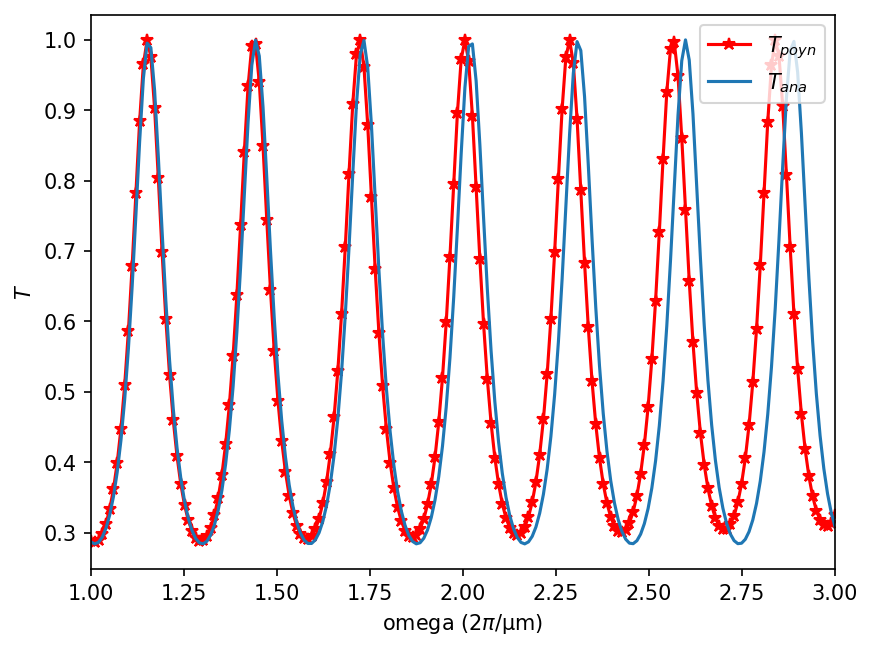

In [11]:
## compare numerical and analytical
plt.figure(dpi=150)
plt.plot(omega/2/np.pi,T_poyn,'r*-',label='$T_{poyn}$')
plt.plot(omega/2/np.pi,T_ana,label='$T_{ana}$')
plt.xlabel("omega ($2\pi$/μm)")
plt.ylabel("$T$")
plt.legend(loc="upper right")
plt.xlim([fmin,fmax])
plt.show()